In [1]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import soundfile as sf
import numpy as np
print(torch.__version__)
print(torchaudio.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from torch.utils.data import DataLoader, TensorDataset, random_split
import os
import pandas as pd

2.10.0+cu130
2.10.0+cu130


In [2]:
import librosa
import numpy as np

def load_audio(file_path, sr=16000):
    y, sr = librosa.load(file_path, sr=sr)
    return y

In [3]:
def build_mimii_pump_dataframe(root_dir):
    records = []
    machine_path= root_dir

    for condition in ["normal", "abnormal"]:
        condition_path = os.path.join(machine_path, condition)

        if not os.path.exists(condition_path):
            continue

        for file in os.listdir(condition_path):
            if file.endswith(".wav"):
                records.append({
                    "machine_id": "id_00",
                    "condition": condition,
                    "file_path": os.path.join(condition_path, file)
                })

    return pd.DataFrame(records)

In [4]:
root_dir = r"data\0_dB_pump\pump\id_00"
df = build_mimii_pump_dataframe(root_dir)

print(df.head())
print(df["condition"].value_counts())

  machine_id condition                                      file_path
0      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000000.wav
1      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000001.wav
2      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000002.wav
3      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000003.wav
4      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000004.wav
condition
normal      1006
abnormal     143
Name: count, dtype: int64


In [6]:
df["label"] = df["condition"].map({"normal": 0, "abnormal": 1})

In [9]:
import torch
import librosa
import numpy as np
from transformers import ASTFeatureExtractor, ASTModel

# Load pretrained AST
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
model = ASTModel.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

model.eval()

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

d:\College\TCG\tcg\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DEBJIT\.cache\huggingface\hub\models--MIT--ast-finetuned-audioset-10-10-0.4593. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (attention): ASTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ASTOutput(
          (d

In [10]:
def extract_embeddings(audio_path):    
    waveform, sr = librosa.load(audio_path, sr=16000)

    inputs = feature_extractor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )
    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token embedding
    embedding = outputs.last_hidden_state[:, 0, :]
    return embedding  # (1, 768)

In [11]:
embeddings = []
for file in df['file_path']:
    embedding = extract_embeddings(file) # (1, 768)
    embeddings.append(embedding.squeeze().numpy())

X = np.vstack(embeddings)

In [200]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.manifold import trustworthiness
import umap

X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2)
X_umap2 = reducer.fit_transform(X_scaled)

print("PCA trust:", trustworthiness(X_scaled, X_pca2))
print("UMAP trust:", trustworthiness(X_scaled, X_umap2))

PCA trust: 0.7899141806044047
UMAP trust: 0.9267541260204926


In [113]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

d_star = np.argmax(cum_var >= 0.95)
print("Approx intrinsic dimension:", d_star)

Approx intrinsic dimension: 147


In [118]:
from sklearn.manifold import trustworthiness
import umap

for d in [2, 5, 10, 20, 30,40]:
    reducer = umap.UMAP(n_components=d)
    X_red = reducer.fit_transform(X_scaled)
    score = trustworthiness(X_scaled, X_red)
    print(d, score)

2 0.9238951067460254
5 0.9464047920342271
10 0.9475492540478364
20 0.9476598558819962
30 0.9469399523573064
40 0.9483033297254252


In [117]:
import hdbscan
from sklearn.metrics import silhouette_score

for d in [5, 10, 15, 20,30,40]:
    reducer = umap.UMAP(n_components=d)
    X_red = reducer.fit_transform(X_scaled)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
    labels = clusterer.fit_predict(X_red)

    if len(set(labels)) > 1:
        score = silhouette_score(X_red[labels!=-1], labels[labels!=-1])
        print(d, score)

5 0.8146495819091797
10 0.7088027596473694
15 0.6524419188499451
20 0.6451033353805542
30 0.7069597244262695
40 0.6860225796699524


In [135]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.argmax(cum_var >= 0.95) + 1
print("Components for 95% variance:", n_95)

Components for 95% variance: 148


In [163]:
pca = PCA(n_components=148)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(1149, 148)


In [259]:
import umap

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    n_components=20,   # use >2 for clustering stability
)

embedding_umap = reducer.fit_transform(X_scaled)

In [260]:
for mcs in [5,10,15,20,25,30 ,40, 60]:
    for ms in [5,10,15, 20, 40]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms
        )
        labels = clusterer.fit_predict(embedding_umap)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = (labels == -1).mean()
        if n_clusters==2 and noise_ratio<=0.01:
            print(mcs, ms, n_clusters, noise_ratio)
            unique_clusters = np.unique(labels)

            for c in unique_clusters:
                count = np.sum(labels == c)
                print(f"Cluster {c}: {count} samples")

5 5 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
5 10 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
5 15 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
5 20 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
5 40 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
10 5 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
10 10 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
10 15 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
10 20 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
10 40 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
15 5 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
15 10 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
15 15 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
15 20 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
15 40 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
20 5 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
20 10 2 0.0
Cluster 0: 82 samples
Cluster 1: 1067 samples
20 15 2 0.0
Cluster 0: 

In [261]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=5
)

cluster_labels = clusterer.fit_predict(embedding_umap)

In [262]:
import pandas as pd

df = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": y   # your ground truth
})

print(pd.crosstab(df["cluster"], df["true_label"]))

true_label     0   1
cluster             
0              0  82
1           1006  61


In [263]:
from sklearn.metrics import adjusted_rand_score

print("ARI:", adjusted_rand_score(y, cluster_labels))

ARI: 0.6564501669436311


In [264]:
import numpy as np

unique_clusters = np.unique(cluster_labels)
print("Clusters found:", unique_clusters)

for c in unique_clusters:
    count = np.sum(cluster_labels == c)
    print(f"Cluster {c}: {count} samples")

Clusters found: [0 1]
Cluster 0: 82 samples
Cluster 1: 1067 samples


In [265]:
embedding_umap.shape

(1149, 20)

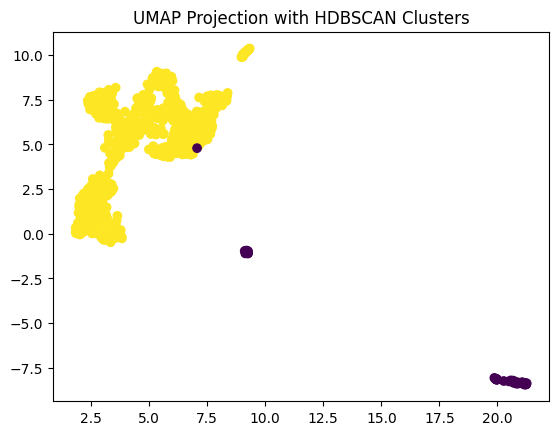

In [266]:
import matplotlib.pyplot as plt

reducer_2d = umap.UMAP(n_components=2)
embedding_2d = reducer_2d.fit_transform(X_scaled)

plt.scatter(embedding_2d[:,0], embedding_2d[:,1], c=cluster_labels)

plt.title("UMAP Projection with HDBSCAN Clusters")
plt.show()

In [268]:
df

,cluster,true_label
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
1144,1,1
1145,1,1
1146,1,1
1147,1,1


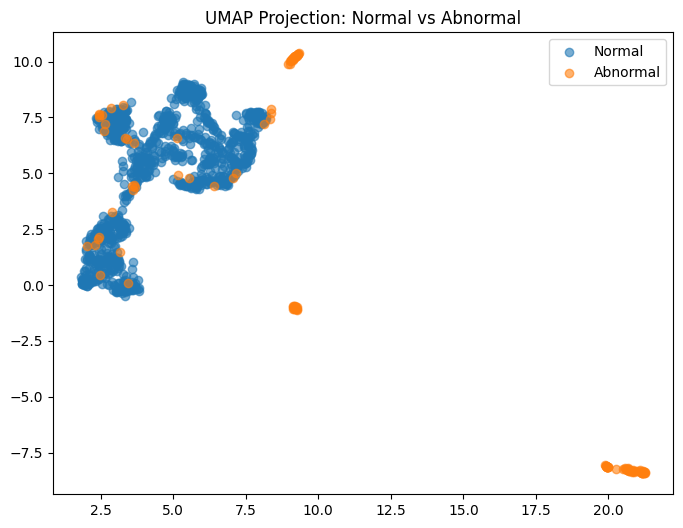

In [269]:
import matplotlib.pyplot as plt
import numpy as np
y=df['true_label']
# Boolean masks
normal_idx = np.array(y) == 0
abnormal_idx = np.array(y) == 1

plt.figure(figsize=(8,6))

plt.scatter(
    embedding_2d[normal_idx, 0],
    embedding_2d[normal_idx, 1],
    label='Normal',
    alpha=0.6
)

plt.scatter(
    embedding_2d[abnormal_idx, 0],
    embedding_2d[abnormal_idx, 1],
    label='Abnormal',
    alpha=0.6
)

plt.legend()
plt.title("UMAP Projection: Normal vs Abnormal")
plt.show()

In [ ]:
path_normal=""
path_abnormal = "" 


In [281]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embedding_umap,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [282]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [283]:
from sklearn.metrics import roc_auc_score

probs = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9176035730787001


In [284]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, probs)
print("PR-AUC:", pr_auc)

PR-AUC: 0.8680008521111562


PCA space:
- Weak density separation
- Better linear separability

UMAP space:
- Stronger density clustering
- Worse linear classification

Therefore the embeddings likely contain Linear discriminative directions but no strong density gaps.

This is why HDBSCAN struggles in PCA space Logistic regression performs better in PCA space, UMAP exaggerates density but does not improve classification

In [290]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embedding_umap,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [291]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

7.04


In [292]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

d:\College\TCG\tcg\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:03:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [293]:
from sklearn.metrics import roc_auc_score, average_precision_score

probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, probs)
pr_auc = average_precision_score(y_test, probs)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9467888495302633
PR-AUC: 0.9093737448667665


In [309]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embedding_umap,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [310]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [311]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [312]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [313]:
from sklearn.metrics import roc_auc_score, average_precision_score

probs_linear = svm_linear.predict_proba(X_test)[:, 1]
probs_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("Linear ROC-AUC:", roc_auc_score(y_test, probs_linear))
print("RBF ROC-AUC:", roc_auc_score(y_test, probs_rbf))

print("Linear PR-AUC:", average_precision_score(y_test, probs_linear))
print("RBF PR-AUC:", average_precision_score(y_test, probs_rbf))

Linear ROC-AUC: 0.9369320807022947
RBF ROC-AUC: 0.9477129216078853
Linear PR-AUC: 0.8813616893624915
RBF PR-AUC: 0.9171902119808176


embedding space is:
- High intrinsic dimension (~147)
- Mostly linearly separable
- Slightly nonlinear boundary
- Not strongly density-separated

UMAP artificially increases density contrast but harms global margin.

Best pipeline is:

AST embeddings
→ Standardize
→ PCA (95%)
→ RBF SVM